In [42]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 500)

In [43]:
df_raw = pd.read_csv("../data/raw/ChestX-ray14/Data_Entry_2017.csv")
df_raw = df_raw.drop(columns="Unnamed: 11")

In [44]:
df_raw.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [45]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [46]:
df_raw.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


In [47]:
view_counts = df_raw["Finding Labels"].value_counts()
view_counts[:20]

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64

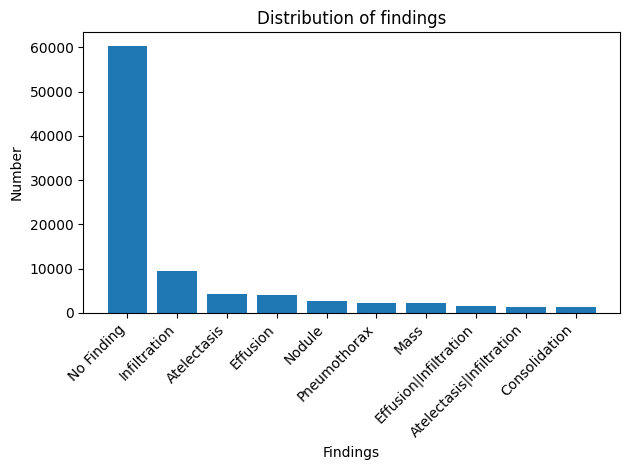

In [48]:
plt.figure()
view_counts = df_raw["Finding Labels"].value_counts()
plt.bar(view_counts[:10].index, view_counts[:10].values)
plt.title("Distribution of findings")
plt.xlabel("Findings")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [49]:
label_sex_crosstab = (df_raw.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_crosstab[:5]

Patient Gender,F,M
Finding Labels,,
No Finding,26439,33922
Infiltration,4164,5383
Effusion,1797,2158
Atelectasis,1612,2603
Pneumothorax,1193,1001


<Figure size 640x480 with 0 Axes>

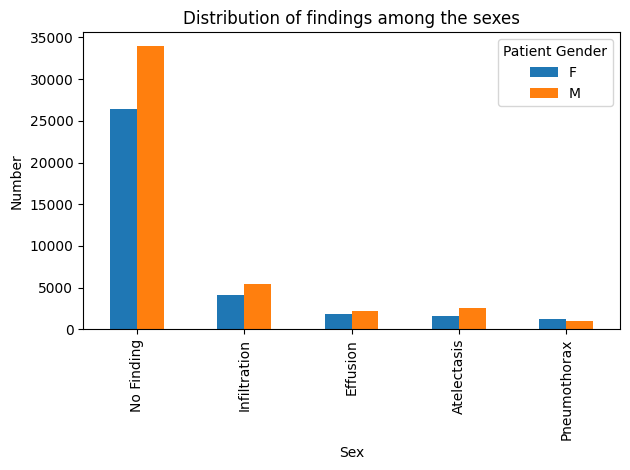

In [50]:
plt.figure()

label_sex_crosstab[:5].plot(kind="bar")
plt.title("Distribution of findings among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

In [51]:
df_drains = pd.read_csv("../data/raw/ChestX-ray14/NIH-CX14_TubeAnnotations_NonExperts_aggregated.csv")

In [52]:
df_drains.head()

,Unnamed: 0,Image Index,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain
0,0,00011831_003.png,1.0,R,1.0,R,1
1,1,00014014_009.png,0.0,NaN,0.0,NaN,0
2,2,00030137_003.png,1.0,L,1.0,L,1
3,3,00018366_038.png,1.0,L,1.0,L,1
4,4,00014251_003.png,1.0,R,1.0,R,1


In [53]:
df_drains.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3543 entries, 0 to 3542
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3543 non-null   int64  
 1   Image Index        3543 non-null   object 
 2   Drain_a1           3543 non-null   float64
 3   Drain_Location_a1  1671 non-null   object 
 4   Drain_a2           3543 non-null   float64
 5   Drain_Location_a2  1669 non-null   object 
 6   Drain              3543 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 193.9+ KB


In [54]:
df_drains["Drain"].value_counts()

Drain
0    1906
1    1637
Name: count, dtype: int64

In [55]:
df_raw.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [56]:
merged = df_raw.merge(df_drains, on='Image Index', how='inner') 

In [57]:
merged.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 0,Drain_a1,Drain_Location_a1,Drain_a2,Drain_Location_a2,Drain
0,00000013_001.png,Emphysema|Pneumothorax,1,13,60,M,AP,3056,2544,0.139,0.139,1005,1.0,R,1.0,R,1
1,00000013_002.png,Emphysema|Pneumothorax,2,13,60,M,AP,3056,2544,0.139,0.139,2324,1.0,R,1.0,R,1
2,00000013_004.png,Effusion|Emphysema|Infiltration|Pneumothorax,4,13,60,M,AP,3056,2544,0.139,0.139,1381,1.0,R,1.0,R,1
3,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,60,M,AP,3056,2544,0.139,0.139,1316,1.0,R,1.0,R,1
4,00000013_010.png,Effusion|Pneumonia|Pneumothorax,10,13,60,M,AP,3056,2544,0.139,0.139,1160,1.0,R,1.0,R,1


why unnamed:0??????????????

In [ ]:
label_sex_crosstab = (merged.explode("Drains").pivot_table(index="Drains", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_crosstab[:5]

KeyError: 'Drains'